# Redes Neuronales II — Backpropagation, Funciones de Activación y Clasificación Binaria

**Estudiante:** Joan Schneider Beltrán Delgado
**Correo institucional:** jsbeltran@ucundinamarca.edu.co
**Asignatura:** Deep Learning – Conceptos
**Institución:** Universidad de Cundinamarca – Posgrados
**Repositorio GitHub:** https://github.com/JoanBeltranAlt/redes-neuronales-ii

## Tabla de contenido

- **0.** Configuración del entorno
- **1.** Funciones de activación: Sigmoide y ReLU
- **2.** Dataset de clasificación binaria (no linealmente separable)
- **3.** Perceptrón simple rediseñado (base de la entrega anterior)
- **4.** Red neuronal de una capa rediseñada (Sigmoide vs. ReLU)
- **5.** MLP "vainilla" desde cero con backpropagation (Sigmoide vs. ReLU)
- **6.** El mismo problema con TensorFlow + Keras
- **7.** El mismo problema con PyTorch
- **8.** Comparación de resultados entre todas las implementaciones
- **9.** Conclusiones

## Objetivo

Esta práctica **rediseña y optimiza** los modelos de la entrega anterior (*Redes Neuronales Básicas*: perceptrón, red de una capa y red multicapa), incorporando:

1. **Funciones de activación** adicionales (ReLU) y su comparación con la sigmoide, aplicadas tanto al perceptrón y la red de una capa como al MLP.
2. **Backpropagation** aplicado a un problema de **clasificación binaria** sobre un dataset **no linealmente separable** (dos semilunas entrelazadas), mucho más exigente que las compuertas lógicas de la entrega anterior — esto permite observar en la práctica por qué el perceptrón y la red de una capa (modelos lineales) no bastan, y por qué se necesita la red multicapa.
3. La arquitectura multicapa final replicada con **dos frameworks especializados de Deep Learning**: **TensorFlow + Keras** y **PyTorch**, para comparar la implementación manual (NumPy) contra las herramientas de la industria.

## Marco conceptual

- **Backpropagation**: algoritmo que calcula el gradiente de la función de pérdida respecto a cada peso de la red, propagando el error desde la capa de salida hacia las capas anteriores mediante la regla de la cadena. Es la base del entrenamiento por descenso de gradiente en redes multicapa.
- **Función de activación Sigmoide**: $\sigma(z) = \frac{1}{1+e^{-z}}$. Mapea cualquier valor real al rango $(0,1)$, útil para interpretar salidas como probabilidades, pero sufre el problema de **desvanecimiento del gradiente** en redes profundas (su derivada máxima es 0.25).
- **Función de activación ReLU** (*Rectified Linear Unit*): $\text{ReLU}(z) = \max(0, z)$. No satura para valores positivos, su gradiente es 0 o 1 (más barato de calcular), y mitiga el desvanecimiento del gradiente, por lo que es la activación estándar en capas ocultas de redes profundas modernas.
- **Clasificación binaria**: tarea de asignar cada muestra a una de dos clases (0 o 1). La capa de salida típicamente usa activación sigmoide y la función de pérdida **binary cross-entropy**.
- **TensorFlow / Keras**: framework de Deep Learning de Google; Keras es su API de alto nivel para definir, entrenar y evaluar redes neuronales de forma declarativa.
- **PyTorch**: framework de Deep Learning de Meta/Facebook, con un estilo más imperativo (define-by-run), ampliamente usado en investigación e industria.


## 0. Configuración del entorno

Este notebook está diseñado para ejecutarse en **Google Colab**. Requiere `numpy` y `matplotlib` (preinstaladas), además de `tensorflow` y `torch` (también preinstaladas en Colab; si no lo están, se instalan con `pip install tensorflow torch`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("NumPy:", np.__version__)

NumPy: 2.5.3


## 1. Funciones de activación: Sigmoide y ReLU

Implementamos ambas funciones y sus derivadas, necesarias para backpropagation, y las visualizamos para comparar su comportamiento.

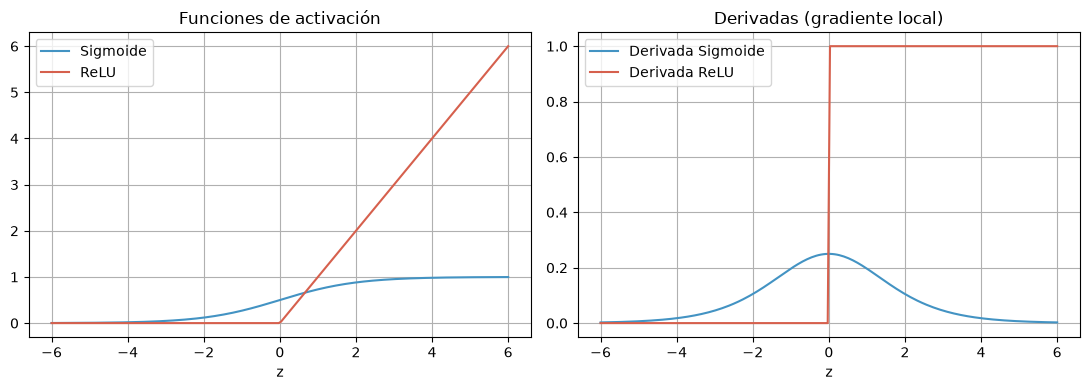

In [2]:
def sigmoid(z):
    """Activación sigmoide: mapea R -> (0, 1). Satura para |z| grande (gradiente ~0)."""
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    """Derivada de la sigmoide en términos de su propia salida 'a'."""
    return a * (1 - a)


def relu(z):
    """Activación ReLU: max(0, z). No satura para z > 0."""
    return np.maximum(0, z)


def relu_derivative(z):
    """Derivada de ReLU: 1 si z > 0, 0 en caso contrario (evaluada sobre la pre-activación z)."""
    return (z > 0).astype(float)


z = np.linspace(-6, 6, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z, sigmoid(z), label="Sigmoide", color="#4393c3")
axes[0].plot(z, relu(z), label="ReLU", color="#d6604d")
axes[0].set_title("Funciones de activación")
axes[0].set_xlabel("z")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(z, sigmoid_derivative(sigmoid(z)), label="Derivada Sigmoide", color="#4393c3")
axes[1].plot(z, relu_derivative(z), label="Derivada ReLU", color="#d6604d")
axes[1].set_title("Derivadas (gradiente local)")
axes[1].set_xlabel("z")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Se observa que la derivada de la sigmoide nunca supera 0.25 y tiende a 0 para $|z|$ grande (**desvanecimiento del gradiente**), mientras que la derivada de ReLU es constante e igual a 1 para $z>0$, lo que permite que el gradiente se propague sin atenuarse a través de muchas capas.

## 2. Dataset de clasificación binaria (no linealmente separable)

A diferencia de las compuertas lógicas de la entrega anterior, aquí usamos un dataset sintético de dos **semilunas entrelazadas** ("moons"), generado con NumPy (sin `scikit-learn`), que **no es linealmente separable** — requiere una red con al menos una capa oculta para clasificarlo correctamente.

X_train: (240, 2) | X_test: (60, 2)


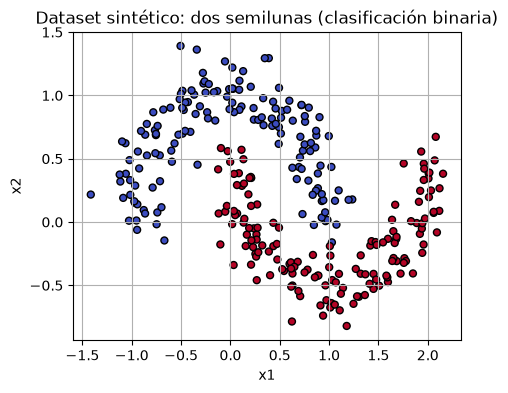

In [3]:
def make_moons(n_samples=300, noise=0.15, seed=42):
    """Genera un dataset sintético de dos semilunas entrelazadas (clasificación binaria)."""
    rng = np.random.RandomState(seed)
    n1 = n_samples // 2
    n2 = n_samples - n1

    # Semiluna superior (clase 0)
    theta1 = np.linspace(0, np.pi, n1)
    x1 = np.stack([np.cos(theta1), np.sin(theta1)], axis=1)

    # Semiluna inferior, desplazada (clase 1)
    theta2 = np.linspace(0, np.pi, n2)
    x2 = np.stack([1 - np.cos(theta2), 1 - np.sin(theta2) - 0.5], axis=1)

    X = np.vstack([x1, x2])
    y = np.hstack([np.zeros(n1), np.ones(n2)])

    X += rng.randn(*X.shape) * noise  # ruido gaussiano

    idx = rng.permutation(len(X))
    return X[idx], y[idx].reshape(-1, 1)


X, y = make_moons(n_samples=300, noise=0.15, seed=42)

# División train/test (80/20) manual con NumPy
n_train = int(0.8 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="coolwarm", edgecolors="k", s=25)
plt.title("Dataset sintético: dos semilunas (clasificación binaria)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

## 3. Perceptrón simple rediseñado

Retomamos el **perceptrón** de la entrega anterior (*Redes Neuronales Básicas*), que originalmente se entrenaba sobre compuertas lógicas linealmente separables (AND). Aquí lo **rediseñamos y ponemos a prueba sobre el dataset de semilunas**, que **no es linealmente separable**, para verificar en la práctica su principal limitación: un perceptrón solo puede trazar una frontera de decisión **lineal** (una recta), por lo que no puede resolver correctamente un problema como este.

In [4]:
def step_function(z):
    """Función de activación escalón: 1 si z >= 0, 0 en caso contrario."""
    return np.where(z >= 0, 1, 0)


class Perceptron:
    """
    Perceptrón simple con regla de aprendizaje clásica (Rosenblatt).
    Código base de la entrega anterior (Redes Neuronales Básicas), reutilizado aquí
    para contrastarlo con un problema no linealmente separable.
    """

    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.lr = learning_rate

    def predict(self, X):
        z = X @ self.weights + self.bias
        return step_function(z)

    def fit(self, X, y, epochs=50):
        history = []
        for epoch in range(epochs):
            y_pred = self.predict(X)
            error = y - y_pred

            self.weights += self.lr * (X.T @ error)
            self.bias += self.lr * np.sum(error)

            loss = np.mean(np.abs(error))
            history.append(loss)
            if (epoch + 1) % 10 == 0:
                print(f"Época {epoch + 1:2d} | Error medio absoluto: {loss:.4f}")

            if loss == 0:
                print("Convergencia alcanzada.")
                break
        return history

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y.flatten()) * 100


perceptron = Perceptron(n_inputs=2, learning_rate=0.1)
history_perceptron = perceptron.fit(X_train, y_train.flatten(), epochs=50)

acc_perceptron_train = perceptron.accuracy(X_train, y_train)
acc_perceptron_test = perceptron.accuracy(X_test, y_test)
print(f"\nPerceptrón -> Accuracy train: {acc_perceptron_train:.1f}% | test: {acc_perceptron_test:.1f}%")

Época 10 | Error medio absoluto: 0.1375
Época 20 | Error medio absoluto: 0.1375
Época 30 | Error medio absoluto: 0.3125
Época 40 | Error medio absoluto: 0.1625
Época 50 | Error medio absoluto: 0.1583

Perceptrón -> Accuracy train: 84.6% | test: 86.7%


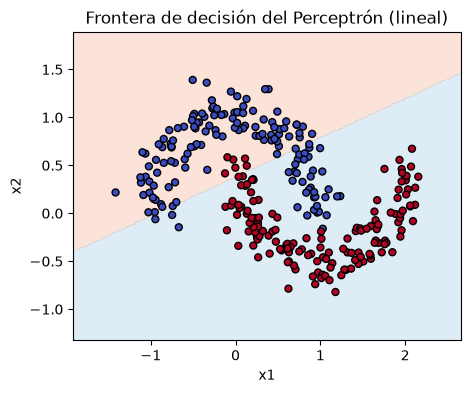

In [5]:
plt.figure(figsize=(5, 4))
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["#f4a582", "#92c5de"])
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="coolwarm", edgecolors="k", s=25)
plt.title("Frontera de decisión del Perceptrón (lineal)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Como se observa, el perceptrón solo logra trazar una **recta** como frontera de decisión, lo cual es insuficiente para separar las dos semilunas entrelazadas — su exactitud queda muy por debajo de lo que logran las redes con capas ocultas más adelante en este notebook. Esto confirma en la práctica la limitación teórica del perceptrón: solo resuelve problemas **linealmente separables**.

## 4. Red neuronal de una capa rediseñada (Sigmoide vs. ReLU)

Retomamos también la **red neuronal de una capa** (sin capas ocultas) de la entrega anterior, originalmente entrenada con activación sigmoide sobre la compuerta OR. Aquí la **rediseñamos** para aceptar tanto **Sigmoide** como **ReLU** como función de activación, y la entrenamos con **backpropagation** (descenso de gradiente) sobre el mismo dataset de semilunas. Al no tener capa oculta, esta red sigue siendo fundamentalmente un **clasificador lineal**, sin importar la activación usada — la activación no lineal en una sola capa de salida no le da a la red la capacidad de curvar su frontera de decisión.

In [6]:
class SingleLayerNN:
    """
    Red neuronal de una sola capa (sin capas ocultas), entrenada con backpropagation.
    Rediseño de la entrega anterior: ahora acepta Sigmoide o ReLU como activación,
    para comparar su efecto incluso en una arquitectura sin capa oculta.
    """

    def __init__(self, n_inputs, n_outputs, activation="sigmoid", learning_rate=0.5, seed=42):
        rng = np.random.RandomState(seed)
        self.W = rng.randn(n_inputs, n_outputs) * 0.1
        self.b = np.zeros((1, n_outputs))
        self.activation = activation
        self.lr = learning_rate

    def _activate(self, z):
        return relu(z) if self.activation == "relu" else sigmoid(z)

    def _activate_derivative(self, z, a):
        return relu_derivative(z) if self.activation == "relu" else sigmoid_derivative(a)

    def forward(self, X):
        self.z = X @ self.W + self.b
        self.a = self._activate(self.z)
        return self.a

    def backward(self, X, y):
        m = X.shape[0]
        error = self.a - y

        dz = error * self._activate_derivative(self.z, self.a)
        dW = (X.T @ dz) / m
        db = np.sum(dz, axis=0, keepdims=True) / m

        self.W -= self.lr * dW
        self.b -= self.lr * db

        return np.mean(error ** 2)

    def fit(self, X, y, epochs=1000, verbose_every=250):
        history = []
        for epoch in range(epochs):
            self.forward(X)
            loss = self.backward(X, y)
            history.append(loss)
            if (epoch + 1) % verbose_every == 0:
                print(f"[{self.activation.upper():7s}] Época {epoch + 1:4d} | Error cuadrático medio: {loss:.4f}")
        return history

    def predict(self, X, threshold=0.5):
        return (self.forward(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y) * 100


single_layer_sigmoid = SingleLayerNN(n_inputs=2, n_outputs=1, activation="sigmoid", learning_rate=0.5, seed=42)
history_single_sigmoid = single_layer_sigmoid.fit(X_train, y_train, epochs=1000, verbose_every=250)

print()

single_layer_relu = SingleLayerNN(n_inputs=2, n_outputs=1, activation="relu", learning_rate=0.1, seed=42)
history_single_relu = single_layer_relu.fit(X_train, y_train, epochs=1000, verbose_every=250)

acc_single_sigmoid_train = single_layer_sigmoid.accuracy(X_train, y_train)
acc_single_sigmoid_test = single_layer_sigmoid.accuracy(X_test, y_test)
acc_single_relu_train = single_layer_relu.accuracy(X_train, y_train)
acc_single_relu_test = single_layer_relu.accuracy(X_test, y_test)

print(f"\nRed 1 capa (Sigmoide) -> Accuracy train: {acc_single_sigmoid_train:.1f}% | test: {acc_single_sigmoid_test:.1f}%")
print(f"Red 1 capa (ReLU)     -> Accuracy train: {acc_single_relu_train:.1f}% | test: {acc_single_relu_test:.1f}%")

[SIGMOID] Época  250 | Error cuadrático medio: 0.1010
[SIGMOID] Época  500 | Error cuadrático medio: 0.0933
[SIGMOID] Época  750 | Error cuadrático medio: 0.0908
[SIGMOID] Época 1000 | Error cuadrático medio: 0.0898

[RELU   ] Época  250 | Error cuadrático medio: 0.0912
[RELU   ] Época  500 | Error cuadrático medio: 0.0911
[RELU   ] Época  750 | Error cuadrático medio: 0.0911
[RELU   ] Época 1000 | Error cuadrático medio: 0.0911

Red 1 capa (Sigmoide) -> Accuracy train: 87.9% | test: 88.3%
Red 1 capa (ReLU)     -> Accuracy train: 88.3% | test: 86.7%


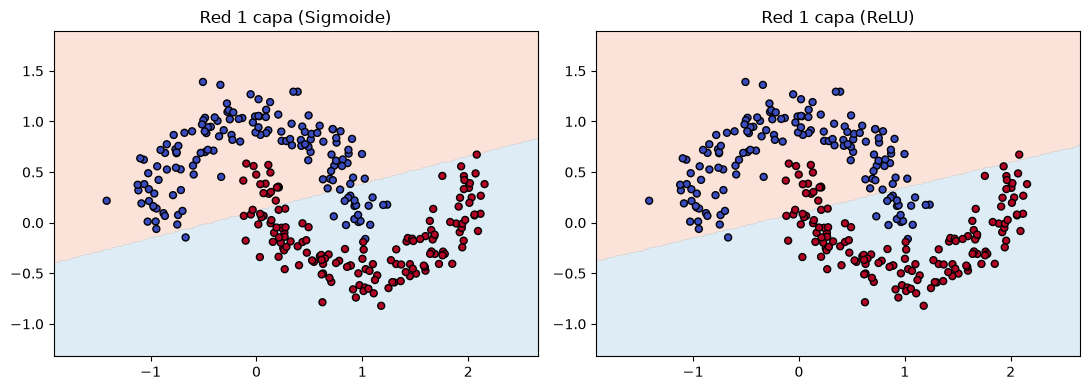

In [7]:
def plot_decision_boundary(predict_fn, X, y, title, ax):
    """Dibuja la frontera de decisión de un modelo sobre una malla de puntos (reutilizada en todo el notebook)."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict_fn(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], colors=["#f4a582", "#92c5de"])
    ax.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap="coolwarm", edgecolors="k", s=25)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_decision_boundary(single_layer_sigmoid.predict, X, y, "Red 1 capa (Sigmoide)", axes[0])
plot_decision_boundary(single_layer_relu.predict, X, y, "Red 1 capa (ReLU)", axes[1])
plt.tight_layout()
plt.show()

Tal como se esperaba, ni la sigmoide ni ReLU le dan a la red de una capa la capacidad de curvar su frontera de decisión — sigue siendo una **recta**, por lo que su exactitud sobre las semilunas se mantiene similar a la del perceptrón. Esto confirma el concepto clave que motiva la siguiente sección: **se necesita al menos una capa oculta** para que la red pueda combinar múltiples fronteras lineales y aproximar una frontera no lineal.

## 5. MLP "vainilla" desde cero con backpropagation

Implementamos un perceptrón multicapa con **una capa oculta configurable** (Sigmoide o ReLU) y capa de salida sigmoide (para clasificación binaria), entrenado con **backpropagation** y descenso de gradiente, usando la pérdida de **entropía cruzada binaria**:

$$ \mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right] $$

Esta pérdida es más adecuada que el error cuadrático medio para clasificación binaria, ya que penaliza con mayor fuerza las predicciones confiadas pero incorrectas.

In [8]:
def binary_cross_entropy(y_true, y_pred, eps=1e-8):
    """Pérdida de entropía cruzada binaria (con recorte para evitar log(0))."""
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


class MLPBinaryClassifier:
    """
    MLP vainilla desde cero para clasificación binaria:
    capa de entrada -> capa oculta (activación configurable) -> capa de salida (sigmoide).
    Entrenado con backpropagation y descenso de gradiente por lotes.
    """

    def __init__(self, n_inputs, n_hidden, activation="relu", learning_rate=0.1, seed=42):
        rng = np.random.RandomState(seed)
        # Inicialización He para ReLU, Xavier para sigmoide (mejores prácticas de inicialización)
        scale = np.sqrt(2.0 / n_inputs) if activation == "relu" else np.sqrt(1.0 / n_inputs)
        self.W1 = rng.randn(n_inputs, n_hidden) * scale
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, 1) * np.sqrt(1.0 / n_hidden)
        self.b2 = np.zeros((1, 1))

        self.activation = activation
        self.lr = learning_rate

    def _activate(self, z):
        return relu(z) if self.activation == "relu" else sigmoid(z)

    def _activate_derivative(self, z, a):
        return relu_derivative(z) if self.activation == "relu" else sigmoid_derivative(a)

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self._activate(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)  # salida siempre sigmoide (probabilidad de clase 1)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]

        # --- Gradiente en la capa de salida (BCE + sigmoide se simplifica a: a2 - y) ---
        dz2 = self.a2 - y
        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # --- Propagación del error hacia la capa oculta ---
        error_hidden = dz2 @ self.W2.T
        dz1 = error_hidden * self._activate_derivative(self.z1, self.a1)
        dW1 = (X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # --- Actualización de parámetros ---
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

        return binary_cross_entropy(y, self.a2)

    def fit(self, X, y, epochs=2000, verbose_every=400):
        history = []
        for epoch in range(epochs):
            self.forward(X)
            loss = self.backward(X, y)
            history.append(loss)
            if (epoch + 1) % verbose_every == 0:
                print(f"[{self.activation.upper():7s}] Época {epoch + 1:4d} | BCE: {loss:.4f}")
        return history

    def predict(self, X, threshold=0.5):
        return (self.forward(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y) * 100

In [9]:
# Entrenamos dos versiones: una con activación Sigmoide y otra con ReLU en la capa oculta
mlp_sigmoid = MLPBinaryClassifier(n_inputs=2, n_hidden=8, activation="sigmoid", learning_rate=0.5, seed=42)
history_sigmoid = mlp_sigmoid.fit(X_train, y_train, epochs=2000, verbose_every=500)

print()

mlp_relu = MLPBinaryClassifier(n_inputs=2, n_hidden=8, activation="relu", learning_rate=0.5, seed=42)
history_relu = mlp_relu.fit(X_train, y_train, epochs=2000, verbose_every=500)

acc_sigmoid_train = mlp_sigmoid.accuracy(X_train, y_train)
acc_sigmoid_test = mlp_sigmoid.accuracy(X_test, y_test)
acc_relu_train = mlp_relu.accuracy(X_train, y_train)
acc_relu_test = mlp_relu.accuracy(X_test, y_test)

print(f"\nMLP (Sigmoide) -> Accuracy train: {acc_sigmoid_train:.1f}% | test: {acc_sigmoid_test:.1f}%")
print(f"MLP (ReLU)     -> Accuracy train: {acc_relu_train:.1f}% | test: {acc_relu_test:.1f}%")

[SIGMOID] Época  500 | BCE: 0.2835
[SIGMOID] Época 1000 | BCE: 0.2812
[SIGMOID] Época 1500 | BCE: 0.2798
[SIGMOID] Época 2000 | BCE: 0.2789

[RELU   ] Época  500 | BCE: 0.1541
[RELU   ] Época 1000 | BCE: 0.0369


[RELU   ] Época 1500 | BCE: 0.0220
[RELU   ] Época 2000 | BCE: 0.0165

MLP (Sigmoide) -> Accuracy train: 88.3% | test: 86.7%
MLP (ReLU)     -> Accuracy train: 99.6% | test: 100.0%


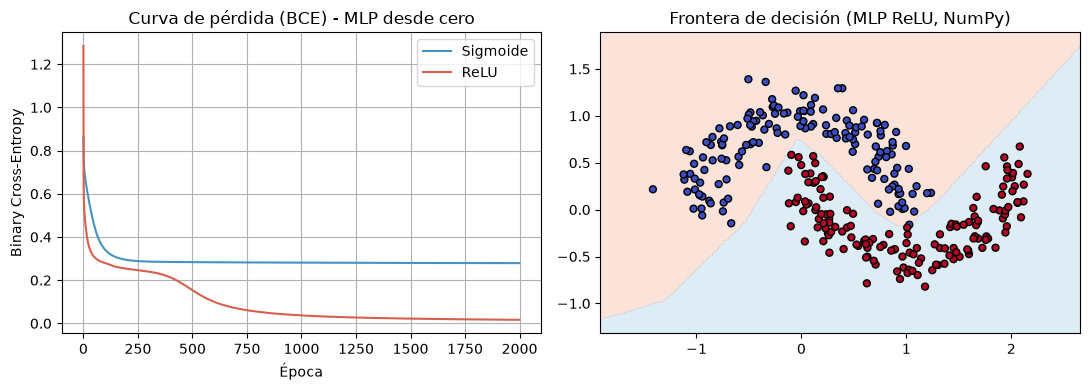

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_sigmoid, label="Sigmoide", color="#4393c3")
axes[0].plot(history_relu, label="ReLU", color="#d6604d")
axes[0].set_title("Curva de pérdida (BCE) - MLP desde cero")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()
axes[0].grid(True)

plot_decision_boundary(mlp_relu.predict, X, y, "Frontera de decisión (MLP ReLU, NumPy)", axes[1])

plt.tight_layout()
plt.show()

Ambas activaciones logran clasificar correctamente el dataset de semilunas, pero **ReLU converge más rápido** (la pérdida baja más abruptamente en las primeras épocas) porque su gradiente no se atenúa como el de la sigmoide, permitiendo pasos de actualización más efectivos.

## 6. El mismo problema con TensorFlow + Keras

Replicamos el mismo problema de clasificación binaria usando la API de alto nivel de Keras, con una arquitectura ligeramente más profunda (2 → 16 → 8 → 1, activaciones ReLU en las capas ocultas y sigmoide en la salida) entrenada con el optimizador **Adam** (descenso de gradiente con momentum adaptativo) en mini-lotes, para comparar contra la implementación manual.

In [11]:
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

model_keras = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu"),  # primera capa oculta
    keras.layers.Dense(8, activation="relu"),   # segunda capa oculta
    keras.layers.Dense(1, activation="sigmoid")  # capa de salida para clasificación binaria
])

model_keras.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_keras.summary()

I0000 00:00:1790441263.179749   27883 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Keras -> Accuracy train: 100.0% | test: 100.0%


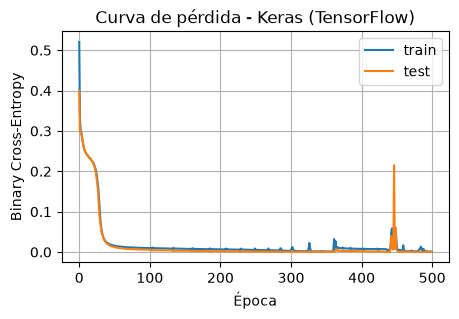

In [12]:
history_keras = model_keras.fit(
    X_train, y_train,
    epochs=500,
    batch_size=16,
    verbose=0,
    validation_data=(X_test, y_test)
)

loss_keras, acc_keras_train = model_keras.evaluate(X_train, y_train, verbose=0)
loss_keras_test, acc_keras_test = model_keras.evaluate(X_test, y_test, verbose=0)

print(f"Keras -> Accuracy train: {acc_keras_train*100:.1f}% | test: {acc_keras_test*100:.1f}%")

plt.figure(figsize=(5, 3))
plt.plot(history_keras.history["loss"], label="train")
plt.plot(history_keras.history["val_loss"], label="test")
plt.title("Curva de pérdida - Keras (TensorFlow)")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.legend()
plt.grid(True)
plt.show()

## 7. El mismo problema con PyTorch

Ahora replicamos la misma arquitectura (2 → 16 → 8 → 1) y el mismo procedimiento de entrenamiento (Adam, mini-lotes) usando PyTorch, cuyo estilo de definición de modelos y bucle de entrenamiento es más explícito (imperativo) que el de Keras.

In [13]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=16,
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)


class TorchMLP(nn.Module):
    """Misma arquitectura que en Keras: 2 -> 16 (ReLU) -> 8 (ReLU) -> 1 (Sigmoide)."""

    def __init__(self, n_inputs=2, n_hidden1=16, n_hidden2=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


model_torch = TorchMLP()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_torch.parameters(), lr=0.01)

PyTorch -> Accuracy train: 100.0% | test: 100.0%


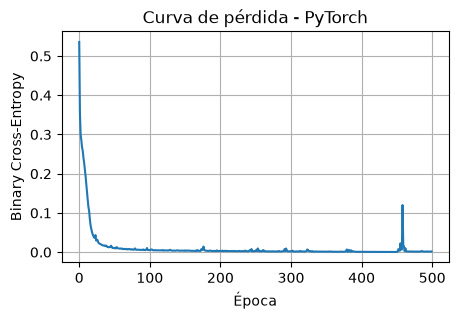

In [14]:
history_torch = []

for epoch in range(500):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model_torch(xb)
        loss = criterion(outputs, yb)
        loss.backward()       # backpropagation automático (autograd)
        optimizer.step()      # actualización de pesos (descenso de gradiente)

    with torch.no_grad():
        epoch_loss = criterion(model_torch(X_train_t), y_train_t).item()
    history_torch.append(epoch_loss)

with torch.no_grad():
    preds_train = (model_torch(X_train_t) >= 0.5).float()
    preds_test = (model_torch(X_test_t) >= 0.5).float()
    acc_torch_train = (preds_train == y_train_t).float().mean().item() * 100
    acc_torch_test = (preds_test == y_test_t).float().mean().item() * 100

print(f"PyTorch -> Accuracy train: {acc_torch_train:.1f}% | test: {acc_torch_test:.1f}%")

plt.figure(figsize=(5, 3))
plt.plot(history_torch)
plt.title("Curva de pérdida - PyTorch")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True)
plt.show()

## 8. Comparación de resultados entre todas las implementaciones

Reunimos aquí los seis modelos entrenados sobre el mismo dataset de semilunas: el perceptrón simple, la red de una capa (Sigmoide y ReLU), el MLP manual (Sigmoide y ReLU), y las réplicas del MLP en Keras y PyTorch (ambas con ReLU).

In [15]:
print("Resumen de exactitud (accuracy) por implementación — dataset de semilunas\n")
print(f"{'Implementación':<28}{'Train':>10}{'Test':>10}")
print("-" * 48)
print(f"{'Perceptrón simple':<28}{acc_perceptron_train:>9.1f}%{acc_perceptron_test:>9.1f}%")
print(f"{'Red 1 capa (Sigmoide)':<28}{acc_single_sigmoid_train:>9.1f}%{acc_single_sigmoid_test:>9.1f}%")
print(f"{'Red 1 capa (ReLU)':<28}{acc_single_relu_train:>9.1f}%{acc_single_relu_test:>9.1f}%")
print(f"{'MLP desde cero (Sigmoide)':<28}{acc_sigmoid_train:>9.1f}%{acc_sigmoid_test:>9.1f}%")
print(f"{'MLP desde cero (ReLU)':<28}{acc_relu_train:>9.1f}%{acc_relu_test:>9.1f}%")
print(f"{'TensorFlow + Keras (ReLU)':<28}{acc_keras_train*100:>9.1f}%{acc_keras_test*100:>9.1f}%")
print(f"{'PyTorch (ReLU)':<28}{acc_torch_train:>9.1f}%{acc_torch_test:>9.1f}%")

Resumen de exactitud (accuracy) por implementación — dataset de semilunas

Implementación                   Train      Test
------------------------------------------------
Perceptrón simple                84.6%     86.7%
Red 1 capa (Sigmoide)            87.9%     88.3%
Red 1 capa (ReLU)                88.3%     86.7%
MLP desde cero (Sigmoide)        88.3%     86.7%
MLP desde cero (ReLU)            99.6%    100.0%
TensorFlow + Keras (ReLU)       100.0%    100.0%
PyTorch (ReLU)                  100.0%    100.0%


## 9. Conclusiones

- **Perceptrón y red de una capa (modelos lineales)**: ambos quedan limitados a fronteras de decisión rectas, por lo que su exactitud sobre el dataset de semilunas (no linealmente separable) es notablemente inferior a la de los modelos con capa oculta — confirmando en la práctica la limitación teórica de los modelos lineales, ya observada en la entrega anterior con las compuertas lógicas.
- **ReLU vs. Sigmoide**: en la capa oculta del MLP, ReLU converge más rápido que la sigmoide porque su derivada no se satura para entradas positivas, evitando el desvanecimiento del gradiente que sí sufre la sigmoide. Por eso ReLU es la activación estándar en capas ocultas de arquitecturas profundas modernas, mientras que la sigmoide se reserva típicamente para la capa de salida en problemas de clasificación binaria.
- **Backpropagation** es el mismo algoritmo matemático (regla de la cadena aplicada capa por capa) tanto en la implementación manual con NumPy (perceptrón, red de una capa y MLP) como en Keras y PyTorch — la diferencia es que estos frameworks lo calculan automáticamente mediante **diferenciación automática (autograd)**, evitando derivar manualmente los gradientes.
- **TensorFlow/Keras** ofrece una API declarativa de alto nivel (`Sequential`, `.compile()`, `.fit()`) que reduce el código necesario para definir y entrenar un modelo.
- **PyTorch** usa un estilo más explícito e imperativo (se define el bucle de entrenamiento manualmente: `forward → loss → backward → step`), lo que da más control pero requiere más código.
- El MLP manual, Keras y PyTorch (los tres con ReLU) alcanzan una exactitud comparable (100%) sobre el dataset de semilunas, confirmando que la lógica matemática subyacente (combinación lineal, activación no lineal, backpropagation, descenso de gradiente) es la misma — lo que cambia es la herramienta usada para expresarla.

## 10. Repositorio GitHub

Enlace del repositorio con este notebook: **https://github.com/JoanBeltranAlt/redes-neuronales-ii**
